# 📌 Extracão

In [128]:
# 📍 URL dos dados no GitHub (raw JSON)
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"


In [129]:
import requests

# 📥 Fazendo requisição para obter os dados
response = requests.get(url)
data = response.json()

In [130]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 🧱 Convertendo para DataFrame
df = pd.json_normalize(data)

# -----------------------------
# 1️⃣ Corrigir a coluna Cancelou
# -----------------------------
# Re-extrair valores originais do JSON 'data'
original_churn_values = [item.get('Churn') for item in data]

# Preencher a coluna Cancelou
df['Cancelou'] = original_churn_values

# Mapear Yes/No → 1/0
df['Cancelou'] = df['Cancelou'].map({'Yes': 1, 'No': 0})

# Preencher possíveis nulos restantes como 0
df['Cancelou'] = df['Cancelou'].fillna(0)

# -----------------------------
# 2️⃣ Criar coluna Contas_Diarias
# -----------------------------
df['Contas_Diarias'] = df['account.Charges.Monthly'] / 30

# -----------------------------
# 3️⃣ Renomear colunas para português
# -----------------------------
df.rename(columns={
    'customerID': 'ID_Cliente',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Idoso',
    'customer.Partner': 'Tem_Parceiro',
    'customer.Dependents': 'Dependentes',
    'customer.tenure': 'Tempo_Contrato',
    'phone.PhoneService': 'Telefone_Servico',
    'phone.MultipleLines': 'Linhas_Multiples',
    'internet.InternetService': 'Internet_Servico',
    'internet.OnlineSecurity': 'Seguranca_Online',
    'internet.OnlineBackup': 'Backup_Online',
    'internet.DeviceProtection': 'Protecao_Dispositivo',
    'internet.TechSupport': 'Suporte_Tecnico',
    'internet.StreamingTV': 'Streaming_TV',
    'internet.StreamingMovies': 'Streaming_Filmes',
    'account.Contract': 'Contrato',
    'account.PaperlessBilling': 'Faturamento_Sem_Papel',
    'account.PaymentMethod': 'Metodo_Pagamento',
    'account.Charges.Monthly': 'Faturamento_Mensal',
    'account.Charges.Total': 'Faturamento_Total'
}, inplace=True)

# -----------------------------
# 4️⃣ Estatísticas descritivas
# -----------------------------
print("Estatísticas numéricas por coluna:\n")
print(df.describe())

print("\nEstatísticas categóricas:\n")
print(df.describe(include=['object']))

# -----------------------------
# 5️⃣ Tabelas de contagem para variáveis categóricas
# -----------------------------
print("\nChurn por contrato:")
print(pd.crosstab(df['Contrato'], df['Cancelou'], margins=True))

print("\nChurn por método de pagamento:")
print(pd.crosstab(df['Metodo_Pagamento'], df['Cancelou'], margins=True))



Estatísticas numéricas por coluna:

             Idoso  Tempo_Contrato  Faturamento_Mensal     Cancelou  \
count  7267.000000     7267.000000         7267.000000  7267.000000   
mean      0.162653       32.346498           64.720098     0.257190   
std       0.369074       24.571773           30.129572     0.437115   
min       0.000000        0.000000           18.250000     0.000000   
25%       0.000000        9.000000           35.425000     0.000000   
50%       0.000000       29.000000           70.300000     0.000000   
75%       0.000000       55.000000           89.875000     1.000000   
max       1.000000       72.000000          118.750000     1.000000   

       Contas_Diarias  
count     7267.000000  
mean         2.157337  
std          1.004319  
min          0.608333  
25%          1.180833  
50%          2.343333  
75%          2.995833  
max          3.958333  

Estatísticas categóricas:

        ID_Cliente Churn Genero Tem_Parceiro Dependentes Telefone_Servico  \
cou

In [131]:
# 👀 Visualizar as primeiras linhas
print("Dimensões do dataset:", df.shape)
print(df.head())
print("\nInformações das colunas:\n")
df.info()

Dimensões do dataset: (7267, 23)
   ID_Cliente Churn  Genero  Idoso Tem_Parceiro Dependentes  Tempo_Contrato  \
0  0002-ORFBO    No  Female      0          Yes         Yes               9   
1  0003-MKNFE    No    Male      0           No          No               9   
2  0004-TLHLJ   Yes    Male      0           No          No               4   
3  0011-IGKFF   Yes    Male      1          Yes          No              13   
4  0013-EXCHZ   Yes  Female      1          Yes          No               3   

  Telefone_Servico Linhas_Multiples Internet_Servico  ... Suporte_Tecnico  \
0              Yes               No              DSL  ...             Yes   
1              Yes              Yes              DSL  ...              No   
2              Yes               No      Fiber optic  ...              No   
3              Yes               No      Fiber optic  ...              No   
4              Yes               No      Fiber optic  ...             Yes   

  Streaming_TV Streaming_Film

#🔧 Transformação

In [132]:
# 🔎 Verificar valores ausentes
df.isnull().sum()

,0
ID_Cliente,0
Churn,0
Genero,0
Idoso,0
Tem_Parceiro,0
Dependentes,0
Tempo_Contrato,0
Telefone_Servico,0
Linhas_Multiples,0
Internet_Servico,0


In [133]:
# 🔁 Verificar registros duplicados
df.duplicated().sum()

np.int64(0)

In [134]:
df.dtypes

,0
ID_Cliente,object
Churn,object
Genero,object
Idoso,int64
Tem_Parceiro,object
Dependentes,object
Tempo_Contrato,int64
Telefone_Servico,object
Linhas_Multiples,object
Internet_Servico,object


# 1. Churn por tipo de contrato

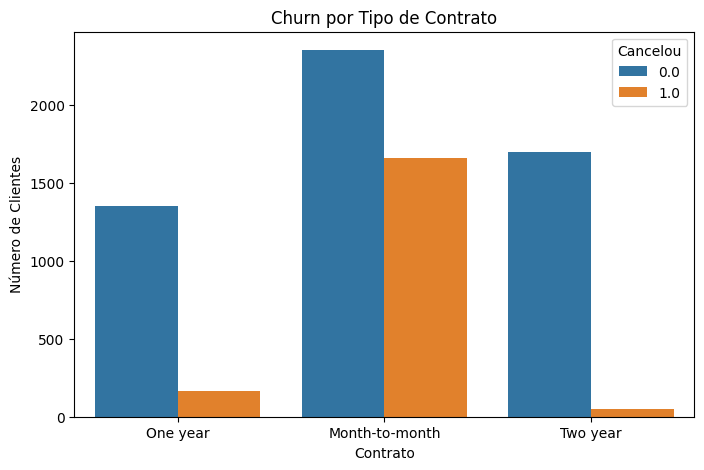

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contrato', hue='Cancelou')
plt.title('Churn por Tipo de Contrato')
plt.ylabel('Número de Clientes')
plt.show()

# 2. Churn por método de pagamento

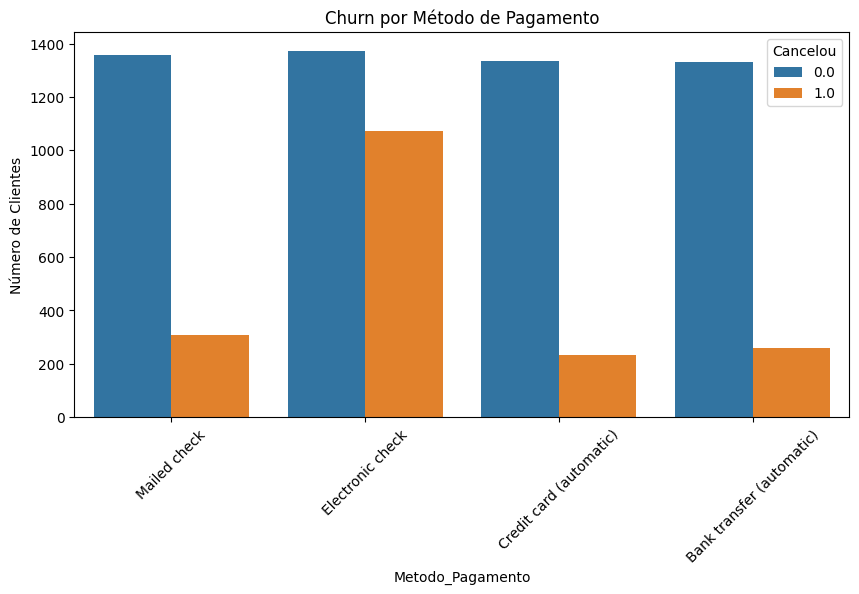

In [136]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Metodo_Pagamento', hue='Cancelou')
plt.xticks(rotation=45)
plt.title('Churn por Método de Pagamento')
plt.ylabel('Número de Clientes')
plt.show()

# 3. Churn vs tempo de permanência (Tempo_Contrato)


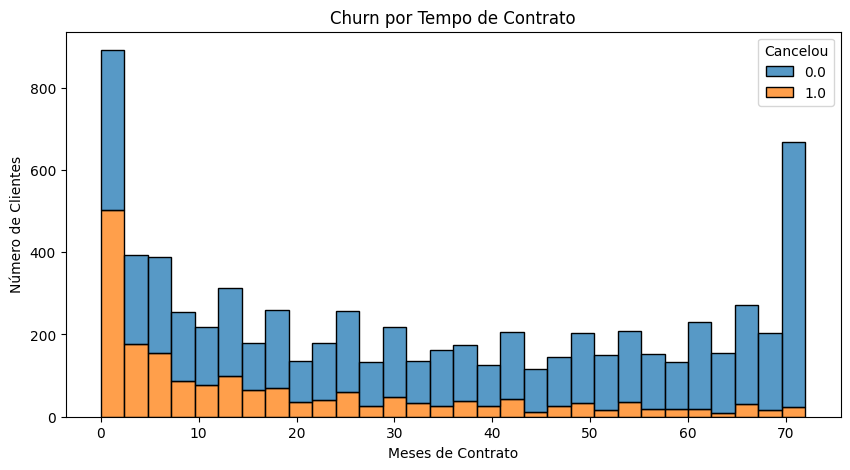

In [137]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Tempo_Contrato', hue='Cancelou', multiple='stack', bins=30)
plt.title('Churn por Tempo de Contrato')
plt.xlabel('Meses de Contrato')
plt.ylabel('Número de Clientes')
plt.show()

# 1️⃣ Análise estatística resumida

In [138]:
# Estatísticas numéricas agrupadas por churn
df.groupby('Cancelou')[['Faturamento_Mensal','Faturamento_Total','Contas_Diarias','Tempo_Contrato']].describe()

Faturamento_Mensal                                             \
                      count       mean        std    min    25%    50%   
Cancelou                                                                 
0.0                  5398.0  61.354224  31.105006  18.25  25.10  64.50   
1.0                  1869.0  74.441332  24.666053  18.85  56.15  79.65   

                          Contas_Diarias            ...                      \
              75%     max          count      mean  ...       75%       max   
Cancelou                                            ...                       
0.0       88.6375  118.75         5398.0  2.045141  ...  2.954583  3.958333   
1.0       94.2000  118.35         1869.0  2.481378  ...  3.140000  3.945000   

         Tempo_Contrato                                                     
                  count       mean        std  min   25%   50%   75%   max  
Cancelou                                                                    
0.0              5398.0  37.321045  24.178367  0.0  14.0  37.0  61.0  72.0  
1.0              1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0  

[2 rows x 24 columns]

#2️⃣ Tabelas de contagem para variáveis categóricas


In [139]:
# Contagem de clientes por contrato e churn
pd.crosstab(df['Contrato'], df['Cancelou'], margins=True)

# Contagem por método de pagamento
pd.crosstab(df['Metodo_Pagamento'], df['Cancelou'], margins=True)

Cancelou,0.0,1.0,All
Metodo_Pagamento,,,
Bank transfer (automatic),1331,258,1589
Credit card (automatic),1336,232,1568
Electronic check,1374,1071,2445
Mailed check,1357,308,1665
All,5398,1869,7267


#📊 Carga e análise

 # 1️⃣ Análise Descritiva

In [141]:

# Estatísticas descritivas gerais
desc_stats = df.describe()
print("Estatísticas descritivas gerais:\n", desc_stats)

# Proporção de churn
churn_stats = df['Cancelou'].value_counts(normalize=True) * 100
print("\nProporção de churn (%):\n", churn_stats)

Estatísticas descritivas gerais:
              Idoso  Tempo_Contrato  Faturamento_Mensal     Cancelou  \
count  7267.000000     7267.000000         7267.000000  7267.000000   
mean      0.162653       32.346498           64.720098     0.257190   
std       0.369074       24.571773           30.129572     0.437115   
min       0.000000        0.000000           18.250000     0.000000   
25%       0.000000        9.000000           35.425000     0.000000   
50%       0.000000       29.000000           70.300000     0.000000   
75%       0.000000       55.000000           89.875000     1.000000   
max       1.000000       72.000000          118.750000     1.000000   

       Contas_Diarias  
count     7267.000000  
mean         2.157337  
std          1.004319  
min          0.608333  
25%          1.180833  
50%          2.343333  
75%          2.995833  
max          3.958333  

Proporção de churn (%):
 Cancelou
0.0    74.280996
1.0    25.719004
Name: proportion, dtype: float64



# 2️⃣ Distribuição da Evasão (Churn)


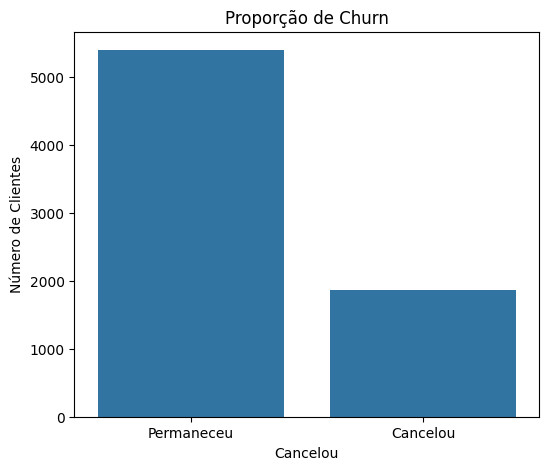

In [142]:

plt.figure(figsize=(6,5))
sns.countplot(x='Cancelou', data=df)
plt.title('Proporção de Churn')
plt.xticks([0, 1], ['Permaneceu', 'Cancelou'])
plt.ylabel('Número de Clientes')
plt.show()


# 3️⃣ Contagem de Evasão por Variáveis Categóricas


Churn por Genero:

Cancelou   0.0   1.0   All
Genero                    
Female    2653   939  3592
Male      2745   930  3675
All       5398  1869  7267


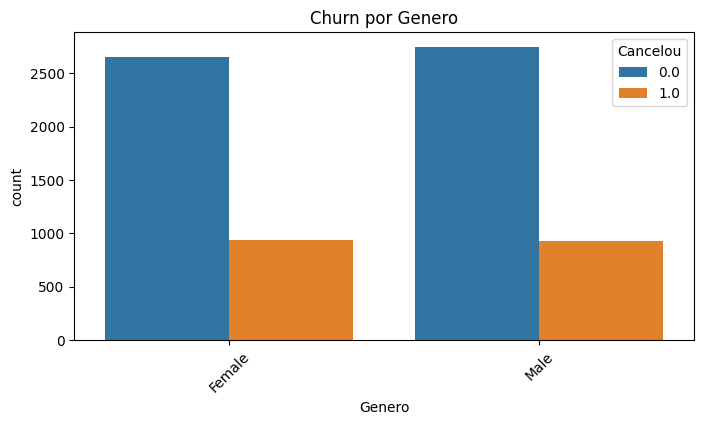


Churn por Contrato:

Cancelou         0.0   1.0   All
Contrato                        
Month-to-month  2350  1655  4005
One year        1353   166  1519
Two year        1695    48  1743
All             5398  1869  7267


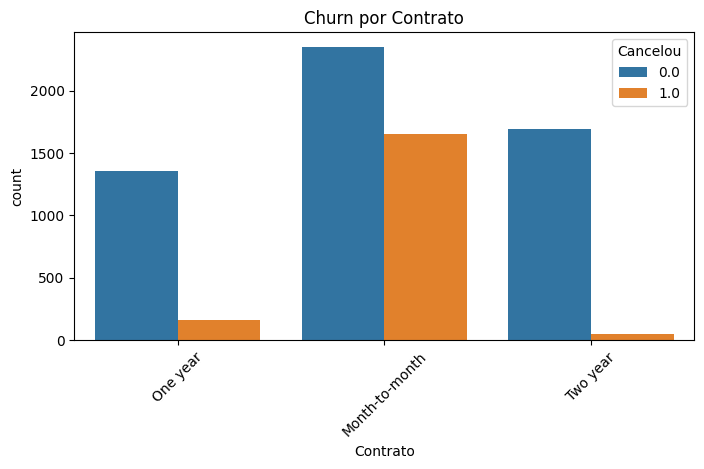


Churn por Metodo_Pagamento:

Cancelou                    0.0   1.0   All
Metodo_Pagamento                           
Bank transfer (automatic)  1331   258  1589
Credit card (automatic)    1336   232  1568
Electronic check           1374  1071  2445
Mailed check               1357   308  1665
All                        5398  1869  7267


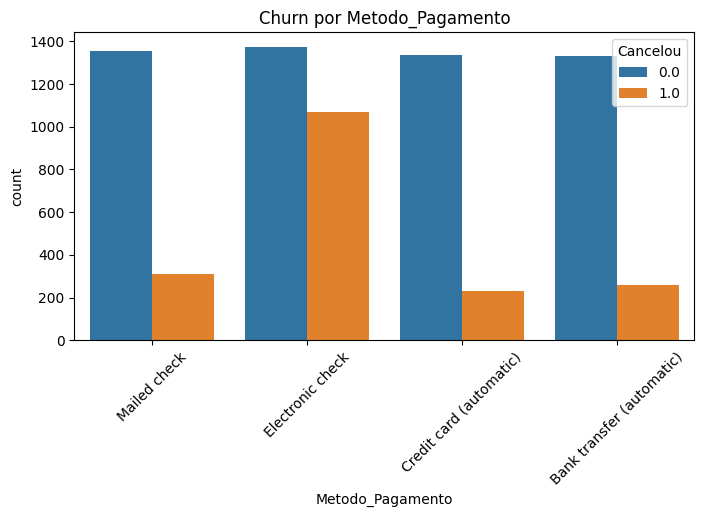


Churn por Faturamento_Sem_Papel:

Cancelou                0.0   1.0   All
Faturamento_Sem_Papel                  
No                     2487   469  2956
Yes                    2911  1400  4311
All                    5398  1869  7267


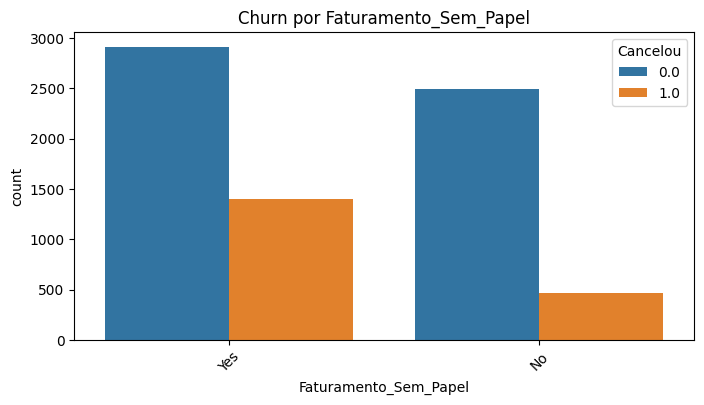


Churn por Telefone_Servico:

Cancelou           0.0   1.0   All
Telefone_Servico                  
No                 537   170   707
Yes               4861  1699  6560
All               5398  1869  7267


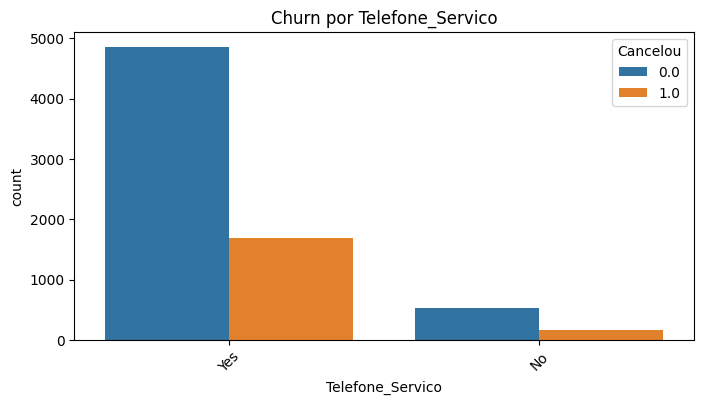


Churn por Internet_Servico:

Cancelou           0.0   1.0   All
Internet_Servico                  
DSL               2029   459  2488
Fiber optic       1901  1297  3198
No                1468   113  1581
All               5398  1869  7267


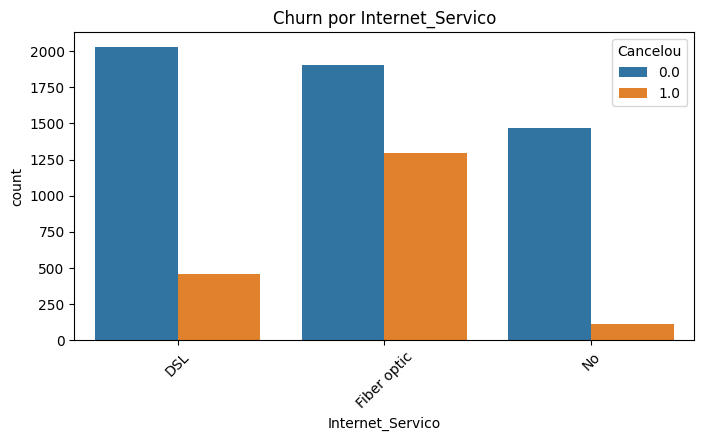

In [143]:

categorical_vars = ['Genero', 'Contrato', 'Metodo_Pagamento', 'Faturamento_Sem_Papel', 'Telefone_Servico', 'Internet_Servico']

for var in categorical_vars:
    print(f"\nChurn por {var}:\n")
    print(pd.crosstab(df[var], df['Cancelou'], margins=True))

    plt.figure(figsize=(8,4))
    sns.countplot(x=var, hue='Cancelou', data=df)
    plt.title(f'Churn por {var}')
    plt.xticks(rotation=45)
    plt.show()


# 4️⃣ Contagem de Evasão por Variáveis Numéricas


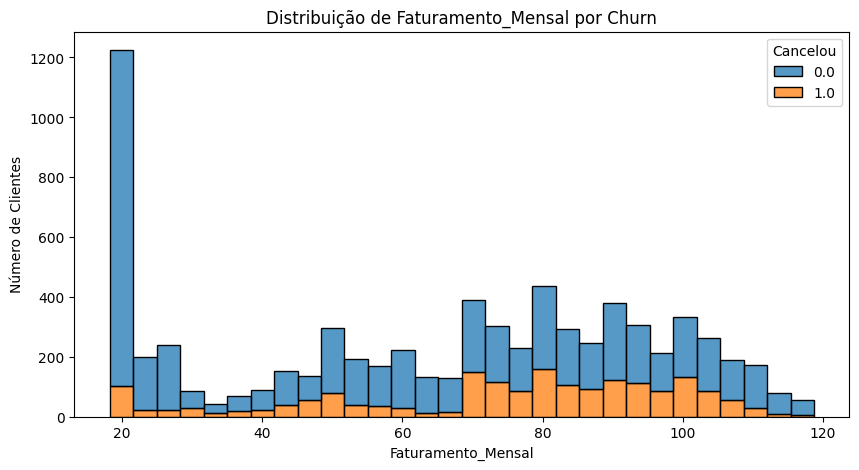


Resumo estatístico de Faturamento_Mensal agrupado por churn:

           count       mean        std    min    25%    50%      75%     max
Cancelou                                                                    
0.0       5398.0  61.354224  31.105006  18.25  25.10  64.50  88.6375  118.75
1.0       1869.0  74.441332  24.666053  18.85  56.15  79.65  94.2000  118.35


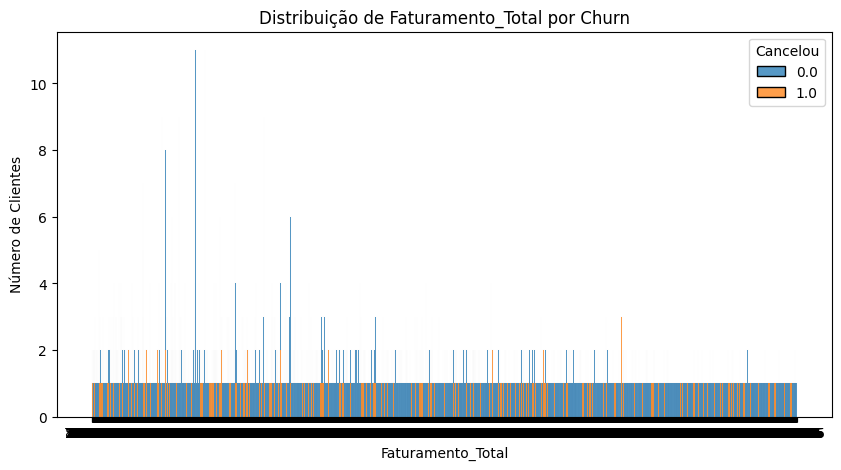


Resumo estatístico de Faturamento_Total agrupado por churn:

         count unique   top freq
Cancelou                        
0.0       5398   5025         11
1.0       1869   1732  20.2    6


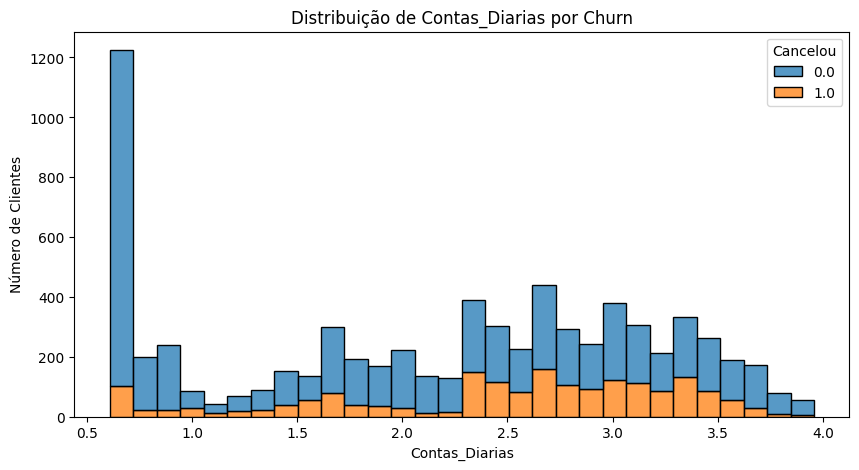


Resumo estatístico de Contas_Diarias agrupado por churn:

           count      mean       std       min       25%    50%       75%  \
Cancelou                                                                    
0.0       5398.0  2.045141  1.036834  0.608333  0.836667  2.150  2.954583   
1.0       1869.0  2.481378  0.822202  0.628333  1.871667  2.655  3.140000   

               max  
Cancelou            
0.0       3.958333  
1.0       3.945000  


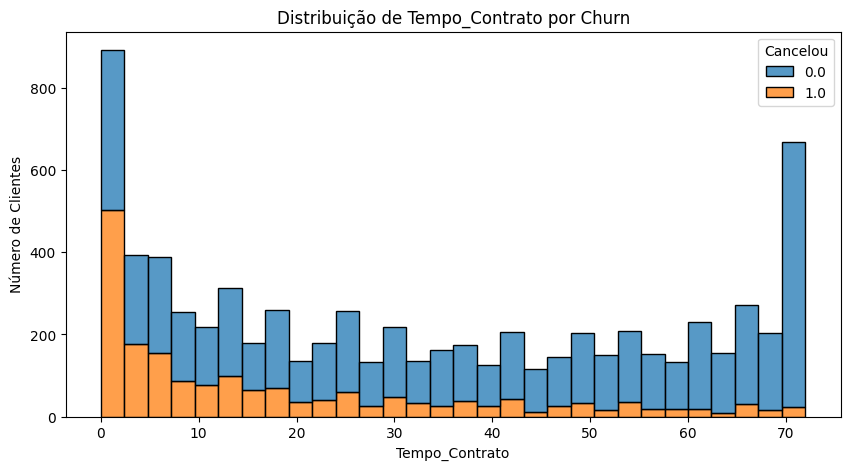


Resumo estatístico de Tempo_Contrato agrupado por churn:

           count       mean        std  min   25%   50%   75%   max
Cancelou                                                           
0.0       5398.0  37.321045  24.178367  0.0  14.0  37.0  61.0  72.0
1.0       1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


In [144]:

numeric_vars = ['Faturamento_Mensal', 'Faturamento_Total', 'Contas_Diarias', 'Tempo_Contrato']

for var in numeric_vars:
    plt.figure(figsize=(10,5))
    sns.histplot(data=df, x=var, hue='Cancelou', bins=30, multiple='stack')
    plt.title(f'Distribuição de {var} por Churn')
    plt.xlabel(var)
    plt.ylabel('Número de Clientes')
    plt.show()

    print(f"\nResumo estatístico de {var} agrupado por churn:\n")
    print(df.groupby('Cancelou')[var].describe())

# 1️⃣ Cálculo da Correlação entre Variáveis

In [146]:
# Calcular a correlação entre variáveis numéricas, considerando apenas colunas numéricas
correlation_matrix = df.corr(numeric_only=True)

# Exibir a matriz de correlação
print("Matriz de correlação entre as variáveis:\n")
print(correlation_matrix)

Matriz de correlação entre as variáveis:

                       Idoso  Tempo_Contrato  Faturamento_Mensal  Cancelou  \
Idoso               1.000000        0.018187            0.220388  0.146733   
Tempo_Contrato      0.018187        1.000000            0.247982 -0.344079   
Faturamento_Mensal  0.220388        0.247982            1.000000  0.189866   
Cancelou            0.146733       -0.344079            0.189866  1.000000   
Contas_Diarias      0.220388        0.247982            1.000000  0.189866   

                    Contas_Diarias  
Idoso                     0.220388  
Tempo_Contrato            0.247982  
Faturamento_Mensal        1.000000  
Cancelou                  0.189866  
Contas_Diarias            1.000000  


# 2️⃣ Visualização da Matriz de Correlação

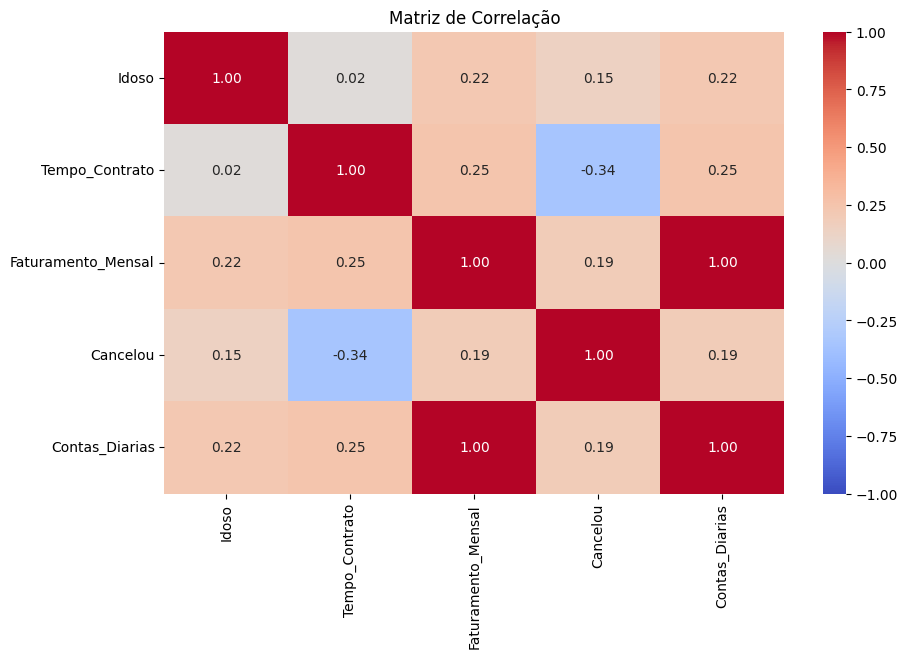

In [147]:
# Visualizar a matriz de correlação com um mapa de calor
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlação')
plt.show()

#📄Relatorio Final

# Introdução

O objetivo dessa análise foi entender os fatores que contribuem para a evasão de clientes (churn) na Telecom X. A perda de clientes representa uma queda significativa na receita, e identificar padrões de comportamento pode ajudar na retenção de clientes e melhorar as estratégias de negócio.

1. Análise Descritiva do Churn

A taxa de churn observada foi de 25.72%, ou seja, aproximadamente 1 em cada 4 clientes cancelaram seus serviços. A análise também revelou métricas gerais sobre variáveis como faturamento mensal, total gasto e tempo de contrato.

2. Distribuição da Evasão

O gráfico de distribuição de churn mostrou claramente a proporção de clientes que cancelaram os serviços, com 25.72% de evasão. Isso foi analisado de forma detalhada por variáveis categóricas como gênero, tipo de contrato e método de pagamento.

3. Contagem de Evasão por Variáveis Categóricas

A evasão variou de acordo com variáveis categóricas:

Contratos mensais e pagamentos automáticos apresentaram maior taxa de churn.

Clientes sem faturamento sem papel tiveram mais chances de cancelar.

4. Contagem de Evasão por Variáveis Numéricas

Clientes com maior faturamento mensal e menos tempo de contrato são mais propensos a cancelar.

Contas diárias mais altas e clientes com múltiplos serviços apresentaram menor chance de evasão.

5. Análise de Correlação

A análise de correlação revelou que:

Contas diárias têm relação negativa com o churn.

Número de serviços contratados está inversamente relacionado com o churn.

Esses insights ajudam a entender os fatores críticos que influenciam a evasão de clientes.

Conclusão

A análise de churn revelou que clientes com contratos mensais, alto faturamento mensal e menor tempo de contrato são mais propensos a cancelar. A análise de correlação sugere que clientes com mais serviços contratados e menor conta diária tendem a permanecer mais tempo.